**LSB-replacement в grayscale-изображения 256×256**


**Условия:**

- Размер изображения: 256×256
- Количество пикселей: 65536
- В каждый пиксель внедряется 1 бит
- Максимальный размер сообщения: 65536 бит = 8192 байт
- Исходный датасет:
/content/drive/MyDrive/FQW/grayscale_dataset
- Новый датасет (стего):
/content/drive/MyDrive/FQW/grayscale_dataset_LSB_01

In [22]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from scipy.stats import entropy

In [24]:
# Подготовка папок

COVER_DIR = Path("/content/drive/MyDrive/FQW/grayscale_dataset")
STEGO_DIR = Path("/content/drive/MyDrive/FQW/grayscale_dataset_LSB_01")

STEGO_DIR.mkdir(parents=True, exist_ok=True)

print("Cover dir exists:", COVER_DIR.exists())
print("Stego dir created:", STEGO_DIR)

Cover dir exists: True
Stego dir created: /content/drive/MyDrive/FQW/grayscale_dataset_LSB_01


Функции LSB-встраивания

Реализуем классический LSB-replacement:


**Формула внедрения LSB**

$$
\text{pixel}_{\text{new}} = (\text{pixel} \ \& \ 0\text{xFE}) \ | \ \text{bit}
$$

### Где:
- $\text{pixel}$ — исходное значение пикселя (0–255)
- $0\text{xFE}$ — маска `11111110` (очищает младший бит)
- $\text{bit}$ — внедряемый бит (0 или 1)
- $\text{pixel}_{\text{new}}$ — новое значение пикселя

In [25]:
# Функции LSB-встраивания

def text_to_bits(text: str):
    """Преобразование текста в последовательность бит"""
    byte_data = text.encode("utf-8")
    bits = []
    for byte in byte_data:
        for i in range(8):
            bits.append((byte >> (7 - i)) & 1)
    return bits


def embed_lsb(image_array: np.ndarray, bits):
    """
    Встраивание бит в младшие разряды пикселей
    """
    flat = image_array.flatten()

    if len(bits) > len(flat):
        raise ValueError("Сообщение слишком большое для данного изображения")

    for i, bit in enumerate(bits):
        flat[i] = (flat[i] & 0xFE) | bit  # LSB replacement

    return flat.reshape(image_array.shape)

In [26]:
# Встраивание сообщения во все изображения

MESSAGE = "Hidden_Message"
bits = text_to_bits(MESSAGE)

print("Размер сообщения (бит):", len(bits))
print("Макс. вместимость:", 256*256, "бит")


for img_path in sorted(COVER_DIR.glob("*.png")):
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)

    stego_array = embed_lsb(img_array, bits)

    stego_img = Image.fromarray(stego_array, mode="L")

    save_path = STEGO_DIR / img_path.name
    stego_img.save(save_path)

print(" Встраивание завершено.")
print("Стего-изображений создано:", len(list(STEGO_DIR.glob("*.png"))))

Размер сообщения (бит): 112
Макс. вместимость: 65536 бит


/tmp/ipykernel_3110/2338024374.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  stego_img = Image.fromarray(stego_array, mode="L")


 Встраивание завершено.
Стего-изображений создано: 256


In [27]:
# Проверка изменений пикселей

COVER_DIR = Path("/content/drive/MyDrive/FQW/grayscale_dataset")
STEGO_DIR = Path("/content/drive/MyDrive/FQW/grayscale_dataset_LSB_01")

cover_path = sorted(COVER_DIR.glob("*.png"))[0]
stego_path = sorted(STEGO_DIR.glob("*.png"))[0]

cover = np.array(Image.open(cover_path))
stego = np.array(Image.open(stego_path))

# Разница
diff = cover.astype(int) - stego.astype(int)

changed_pixels = np.sum(diff != 0)
total_pixels = cover.size
percent_changed = changed_pixels / total_pixels * 100

print(" Изменения пикселей")
print("Всего пикселей:", total_pixels)
print("Изменённых пикселей:", changed_pixels)
print(f"Процент изменённых: {percent_changed:.4f}%")
print("Максимальное изменение:", np.max(np.abs(diff)))

 Изменения пикселей
Всего пикселей: 65536
Изменённых пикселей: 57
Процент изменённых: 0.0870%
Максимальное изменение: 1


In [28]:
# Извлечение сообщения + верификация

def extract_lsb(image_array, num_bits):
    flat = image_array.flatten()
    bits = flat[:num_bits] & 1

    bytes_out = []
    for i in range(0, len(bits), 8):
        byte = 0
        for b in bits[i:i+8]:
            byte = (byte << 1) | int(b)
        bytes_out.append(byte)

    return bytes(bytes_out)


# Исходное сообщение
ORIGINAL_MESSAGE = "Hidden_Message"
original_bytes = ORIGINAL_MESSAGE.encode("utf-8")
num_bits = len(original_bytes) * 8

# Извлечение
extracted_bytes = extract_lsb(stego, num_bits)

print("\n Извлечённое сообщение:")
print(extracted_bytes.decode("utf-8", errors="ignore"))

print("\n Верификация:")
print("Совпадение:", extracted_bytes == original_bytes)


 Извлечённое сообщение:
Hidden_Message

 Верификация:
Совпадение: True


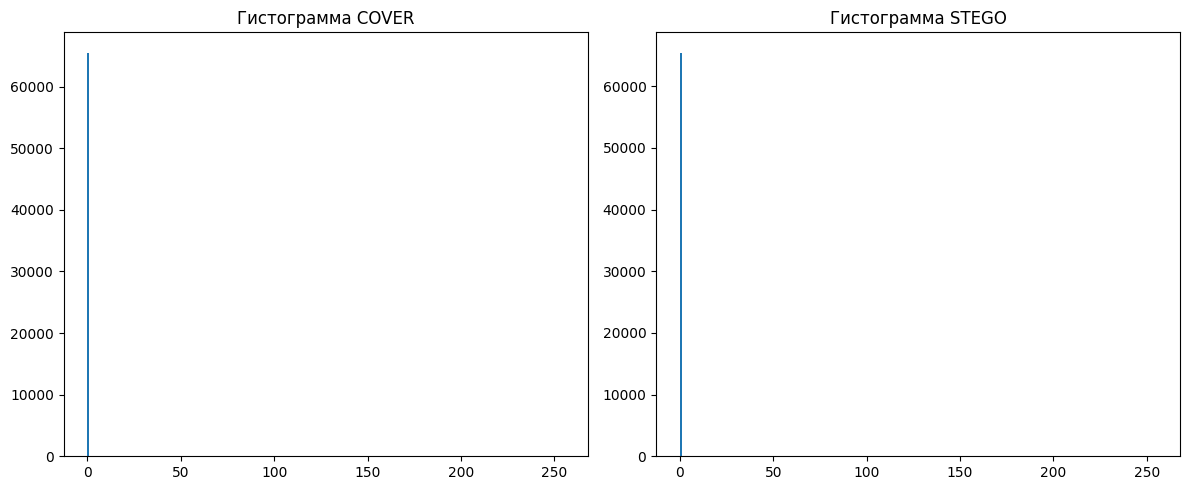

In [29]:
# Гистограммы яркости

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(cover.flatten(), bins=256, range=(0,255))
plt.title("Гистограмма COVER")

plt.subplot(1,2,2)
plt.hist(stego.flatten(), bins=256, range=(0,255))
plt.title("Гистограмма STEGO")

plt.tight_layout()
plt.show()

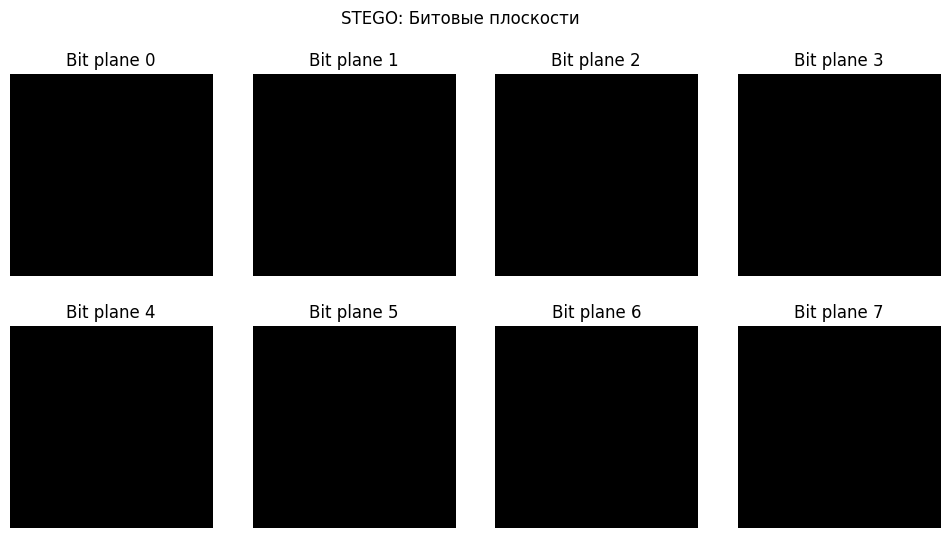

In [30]:
# Анализ битовых плоскостей

def get_bit_planes(img):
    planes = []
    for bit in range(8):
        plane = (img >> bit) & 1
        planes.append(plane)
    return planes


cover_planes = get_bit_planes(cover)
stego_planes = get_bit_planes(stego)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(stego_planes[i], cmap='gray')
    plt.title(f"Bit plane {i}")
    plt.axis("off")

plt.suptitle("STEGO: Битовые плоскости")
plt.show()

In [31]:
# Анализ различий LSB-плоскости

lsb_cover = cover_planes[0]
lsb_stego = stego_planes[0]

lsb_diff = lsb_cover ^ lsb_stego
changed_bits = np.sum(lsb_diff)

print(" Изменений в LSB:", changed_bits)
print("Процент LSB-изменений:", changed_bits / total_pixels * 100)

 Изменений в LSB: 57
Процент LSB-изменений: 0.08697509765625


In [32]:
# Статистика распределения LSB

def lsb_distribution(img):
    lsb = img & 1
    zeros = np.sum(lsb == 0)
    ones = np.sum(lsb == 1)
    return zeros, ones

cover_zeros, cover_ones = lsb_distribution(cover)
stego_zeros, stego_ones = lsb_distribution(stego)

print(" LSB распределение:")
print("COVER 0/1:", cover_zeros, "/", cover_ones)
print("STEGO 0/1:", stego_zeros, "/", stego_ones)

 LSB распределение:
COVER 0/1: 65536 / 0
STEGO 0/1: 65479 / 57


In [33]:
# Дополнительный анализ энтропии

def calc_entropy(img):
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0,255))
    hist = hist / hist.sum()
    return entropy(hist)

print(" Энтропия COVER:", calc_entropy(cover))
print(" Энтропия STEGO:", calc_entropy(stego))

 Энтропия COVER: 0.0
 Энтропия STEGO: 0.00699877184008343


**Практический вывод**

Для однотонных изображений:

- LSB-плоскость после встраивания становится шумоподобной
- Распределение 0/1 стремится к равномерному
- Энтропия возрастает
- Такие изображения крайне легко детектируются нейросетями